<a href="https://colab.research.google.com/github/TCU-DCDA/WRIT20833-2025/blob/main/notebooks/homework/WRIT20833_HW4-1_Term_Frequency_Sentiment_F25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW4-1: Term Frequency and Sentiment Analysis
**Due: October 5th**  
**Intro to Coding in the Humanities - Midterm Assignment Part 1**

**Student Name:** _Ryan Sanchez_

**Upload:** `LASTNAME_HW4-1_F25.ipynb`

---

## Assignment Overview

This assignment marks your first extensive analysis of a text-heavy dataset of your choosing. The goal is not just to run analytical tools, but to experience the process of moving from assumptions to data-driven insights. You'll practice forming hypotheses, testing them against actual data, and allowing your understanding to evolve based on what you discover.

In our digital age, we're constantly exposed to two very different paths to forming opinions and understanding the world. One path leads from genuine phenomena through careful data collection and analysis toward real insight, knowledge, and wisdom. The other path starts with social media impressions and moves through cherry-picked evidence and narrative scaffolding toward rigid ideological positions. Through this assignment, you'll experience the first path—the harder but more rewarding journey of letting data challenge and refine your thinking.

**Important Philosophy**: Being "wrong" in your initial predictions is not a failure—it's a sign of genuine learning and intellectual growth. The best insights often come from discovering that reality differs from our assumptions. When your data surprises you, that's when real learning happens.

**Collaboration Policy**: You may work together with classmates to solve technical challenges and discuss methods, but each student must choose their own unique dataset and complete their own analysis.

## Step 1: Dataset Loading and Initial Exploration
*Moving from Scraped Data to Analysis-Ready Dataset*

### Loading Your Cultural Dataset

You'll use the cultural dataset you collected using the Instant Data Scraper in our previous lesson. This should be a CSV file with rich text content suitable for both term frequency and sentiment analysis.

In [2]:
# Setup: Import all libraries we'll need
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import re

# Display settings for better output
pd.options.display.max_rows = 20
pd.options.display.max_columns = 10

print("📚 Libraries imported - ready for analysis!")

📚 Libraries imported - ready for analysis!


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Load your scraped cultural data
# Replace 'your_filename.csv' with your actual file name

# If you're in Google Colab, upload your file first:
# from google.colab import files
# uploaded = files.upload()

# Load your data (fill in your filename)
df = pd.read_csv('/content/drive/MyDrive/WRIT20833/FinalProject/PLTR_YTcomments_final.csv')  # Replace with your CSV filename

print(f"✅ Dataset loaded successfully!")
print(f"Dataset contains {len(df)} items")

✅ Dataset loaded successfully!
Dataset contains 2131 items


In [5]:
# loaded in NEW dataset with over 2000 comments

### Technical Checkpoint 1: Data Loading Reality Check

In [11]:
# Checkpoint 1: Verify your data loaded correctly
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Replace 'YOUR_TEXT_COLUMN' with your actual text column name
text_column = 'comment'  # Fill in your main text column name

print(f"Text column has {df[text_column].isna().sum()} missing values")
print(f"Sample text: {df[text_column].iloc[0][:200]}")

Dataset shape: (2131, 12)
Columns: ['recency', 'comment_link', 'comment', 'number_of_likes', 'number_of_replies', 'clean_text_sentiment', 'words', 'meaningful_words', 'sentiment_score', 'processed_for_topics', 'dominant_topic', 'topic_probability']
Text column has 0 missing values
Sample text: The worst thing in the world is that we have no comic book heroes but we have so many comic book villains


In [7]:
# Palantir youtube video comments are loaded in successfully

In [6]:
# Explore your dataset structure
print("=== DATASET EXPLORATION ===")
print(f"Total entries: {len(df)}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nFirst few rows:")
df.head()

=== DATASET EXPLORATION ===
Total entries: 2131

Data types:
recency                  object
comment_link             object
comment                  object
number_of_likes          object
number_of_replies        object
clean_text_sentiment     object
words                    object
meaningful_words         object
sentiment_score         float64
processed_for_topics     object
dominant_topic            int64
topic_probability       float64
dtype: object

First few rows:


,recency,comment_link,comment,number_of_likes,number_of_replies,...,meaningful_words,sentiment_score,processed_for_topics,dominant_topic,topic_probability
0,3 months ago,https://www.youtube.com/watch?v=DZ95Gmvg_D4&lc...,The worst thing in the world is that we have n...,5.3K,122 replies,...,"['worst', 'comic', 'book', 'heroes', 'many', '...",-0.8442,"['worst', 'comic', 'book', 'hero', 'many', 'co...",2,0.969
1,2 months ago,https://www.youtube.com/watch?v=DZ95Gmvg_D4&lc...,CEO is scarily unhinged.. You can tell he's on...,1.8K,36 replies,...,"['ceo', 'scarily', 'unhinged', 'tell', 'seriou...",-0.0772,"['ceo', 'scarily', 'unhinged', 'tell', 'seriou...",4,0.712
2,6 months ago,https://www.youtube.com/watch?v=DZ95Gmvg_D4&lc...,We are not outnumbered. We're out-organized.,11K,214 replies,...,"['outnumbered', 'organized']",0.0000,"['outnumbered', 'organized']",4,0.893
3,1 month ago,https://www.youtube.com/watch?v=DZ95Gmvg_D4&lc...,"Why do movies, comics, and video games always ...",728,17 replies,...,"['movies', 'comics', 'games', 'always', 'show'...",0.7650,"['movie', 'comic', 'game', 'always', 'show', '...",4,0.978
4,5 months ago,https://www.youtube.com/watch?v=DZ95Gmvg_D4&lc...,"""Bad times are good for Palantir"" says the CEO...",2.4K,16 replies,...,"['says', 'ceo', 'tells', 'government', 'whether']",0.3182,"['say', 'ceo', 'tell', 'government', 'whether']",0,0.953


### 📝 My Initial Predictions:

 # From memes, to interview clips, to opinion pieces that I've seen on social media (typically TikTok or Instagram), I would expect that this YouTube comment section is going to skew toward being heavily negative.


---

## Step 2: Text Preparation for Analysis
*Building on HW1 Text Processing Skills*

Just like in HW1, we need to prepare our text for analysis. But this time, we're preparing for TWO types of analysis: term frequency (like HW1) and sentiment analysis (new!).

In [7]:
# Enhanced stopwords list for Palantir cultural dataset
stopwords = [
    # Basic stopwords from HW1
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you", "your", "yours",
    "yourself", "yourselves", "he", "him", "his", "himself", "she", "her", "hers",
    "herself", "it", "its", "itself", "they", "them", "their", "theirs", "themselves",
    "what", "which", "who", "whom", "this", "that", "these", "those", "am", "is",
    "are", "was", "were", "be", "been", "being", "have", "has", "had", "having",
    "do", "does", "did", "doing", "a", "an", "the", "and", "but", "if", "or",
    "because", "as", "until", "while", "of", "at", "by", "for", "with", "about",
    "against", "between", "into", "through", "during", "before", "after", "above",
    "below", "to", "from", "up", "down", "in", "out", "on", "off", "over", "under",
    "again", "further", "then", "once", "here", "there", "when", "where", "why",
    "how", "all", "any", "both", "each", "few", "more", "most", "other", "some",
    "such", "no", "nor", "not", "only", "own", "same", "so", "than", "too", "very",
    "s", "t", "can", "will", "just", "don", "should", "now", "ve", "ll", "amp",

    # Additional common words for cultural data
    "also", "would", "could", "get", "go", "one", "two", "see", "time", "way", "may",
    "said", "say", "new", "first", "last", "long", "little", "much", "well", "still",

    # === Domain-specific stopwords (Palantir dataset tuning) ===
    # Generic nouns and pronouns that dominate but don't reveal ethical context
    "people", "company", "us", "world", "re", "like", "want", "need", "never", "times", "video",

    # Sentiment or vague moral terms that are too broad for ethical specificity
    "good", "bad", "great", "thank", "thanks", "love", "hate", "hope",

    # Contextually empty verbs/adjectives often repeated in comment threads
    "know", "think", "make", "made", "really", "lot", "thing", "things", "way",
     "palantir", "even",
    "guys",
    "used",
    "use",
    "real"
]


print(f"✅ Stopwords list loaded: {len(stopwords)} words to filter out")

✅ Stopwords list loaded: 185 words to filter out


In [10]:
# further adjusting stopwords list so that it is tailored to my dataset, allowing us to come to some conclusions



In [8]:
# Text processing functions (building on HW1 approach)
def split_into_words(text):
    """Split text into words (same approach as HW1)"""
    if pd.isna(text):  # Handle missing text
        return []
    lowercase_text = str(text).lower()
    # Split text into words by looking for places where letters/numbers are not present
    split_words = re.split("\\W+", lowercase_text)
    return [word for word in split_words if word]  # Remove empty strings

def clean_for_sentiment(text):
    """Clean text for sentiment analysis (keep punctuation!)"""
    if pd.isna(text):
        return ""
    # Keep punctuation and capitalization - VADER needs them!
    return str(text).strip()

print("✅ Text processing functions ready")

✅ Text processing functions ready


In [9]:
# Drop missing comments and ensure string type
df = df.dropna(subset=['comment'])
df['comment'] = df['comment'].astype(str)

# Apply text cleaning
df['clean_text_sentiment'] = df['comment'].apply(clean_for_sentiment)
df['words'] = df['comment'].apply(split_into_words)

# Remove stopwords safely
df['meaningful_words'] = df['words'].apply(
    lambda word_list: [word for word in word_list if word not in stopwords] if isinstance(word_list, list) else []
)

print("✅ Text cleaning complete")
print(f"Sample cleaned text for sentiment: {df['clean_text_sentiment'].iloc[0][:100]}...")
print(f"Sample meaningful words: {df['meaningful_words'].iloc[0][:10]}")


✅ Text cleaning complete
Sample cleaned text for sentiment: The worst thing in the world is that we have no comic book heroes but we have so many comic book vil...
Sample meaningful words: ['worst', 'comic', 'book', 'heroes', 'many', 'comic', 'book', 'villains']


### Technical Checkpoint 2: Text Cleaning Verification

In [12]:
# Checkpoint 2: Check your cleaning worked
sample_text = df[text_column].iloc[0]
print(f"Original: {sample_text[:100]}")
print(f"For sentiment: {df['clean_text_sentiment'].iloc[0][:100]}")
print(f"Meaningful words: {df['meaningful_words'].iloc[0][:15]}")
# Should show: sentiment text keeps punctuation, meaningful words exclude stopwords

Original: The worst thing in the world is that we have no comic book heroes but we have so many comic book vil
For sentiment: The worst thing in the world is that we have no comic book heroes but we have so many comic book vil
Meaningful words: ['worst', 'comic', 'book', 'heroes', 'many', 'comic', 'book', 'villains']


---

## Step 3: Term Frequency Analysis
*Building on HW1 Word Counting Skills*

Now let's analyze which words appear most frequently in your cultural dataset, just like you did in HW1 but with more sophisticated text processing.

In [13]:
from collections import Counter

# Combine all meaningful words from your dataset (for Palantir-related comment analysis)
all_meaningful_words = [
    # Core business and tech context
    "palantir", "data", "ai", "artificial", "intelligence", "technology", "software",
    "analytics", "algorithm", "machine", "learning", "innovation", "platform", "cloud",
    "surveillance", "tracking", "monitoring", "database", "predictive", "security",
    "defense", "government", "military", "contract", "company", "business", "startup",
    "enterprise", "investor", "profit", "market", "stock", "valuation", "share", "growth",

    # Ethics, privacy, and morality
    "privacy", "ethics", "ethical", "integrity", "morality", "values", "responsibility",
    "consent", "transparency", "trust", "accountability", "freedom", "rights",
    "surveillance", "invasive", "invasiveness", "control", "exploitation",
    "corruption", "power", "authority", "secrecy", "manipulation", "oppression",
    "exposure", "whistleblower", "accountable",

    # Public perception and emotion
    "creepy", "dangerous", "innovative", "brilliant", "disturbing", "cool", "scary",
    "controversial", "useful", "amazing", "unethical", "fascinating", "intense",
    "dark", "bold", "powerful", "greedy", "secretive", "dystopian", "trustworthy",
    "questionable", "evil", "intelligent", "progressive", "ambitious", "complex",

    # Government, security, and society
    "cia", "nsa", "fbi", "spy", "spying", "surveillance", "control", "military",
    "defense", "contractor", "war", "terrorism", "security", "law", "policy",
    "government", "state", "democracy", "freedom", "rights", "citizens", "society",

    # Corporate behavior and capitalism
    "profit", "wealth", "capitalism", "greed", "investment", "market", "stock",
    "ipo", "founder", "leadership", "ceo", "management", "team", "startup",
    "corporate", "business", "economy", "growth", "revenue", "expansion", "strategy",
    "success", "power", "influence", "control", "monopoly", "competition", "dominance"
]

for word_list in df['meaningful_words']:
    all_meaningful_words.extend(word_list)

# Count word frequencies (same as HW1)
word_frequency = Counter(all_meaningful_words)
top_words = word_frequency.most_common(20)  # Get top 20 words

print("🔤 TERM FREQUENCY ANALYSIS RESULTS")
print("=" * 40)
print(f"Total words analyzed: {len(all_meaningful_words):,}")
print(f"Unique words found: {len(word_frequency):,}")
print(f"\nTop 20 most frequent words:")

for i, (word, count) in enumerate(top_words, 1):
    print(f"{i:2d}. {word:<15} ({count:,} times)")


🔤 TERM FREQUENCY ANALYSIS RESULTS
Total words analyzed: 23,965
Unique words found: 3,061

Top 20 most frequent words:
 1. evil            (149 times)
 2. thiel           (134 times)
 3. power           (130 times)
 4. tech            (113 times)
 5. peter           (103 times)
 6. ceo             (93 times)
 7. data            (82 times)
 8. government      (82 times)
 9. right           (75 times)
10. karp            (74 times)
11. ai              (73 times)
12. war             (69 times)
13. companies       (67 times)
14. reality         (66 times)
15. technology      (65 times)
16. work            (65 times)
17. feel            (65 times)
18. human           (64 times)
19. enough          (62 times)
20. point           (61 times)


In [15]:
# I used AI to generate a longer list of stopwords to scope in on privacy, ethics, etc for palantir

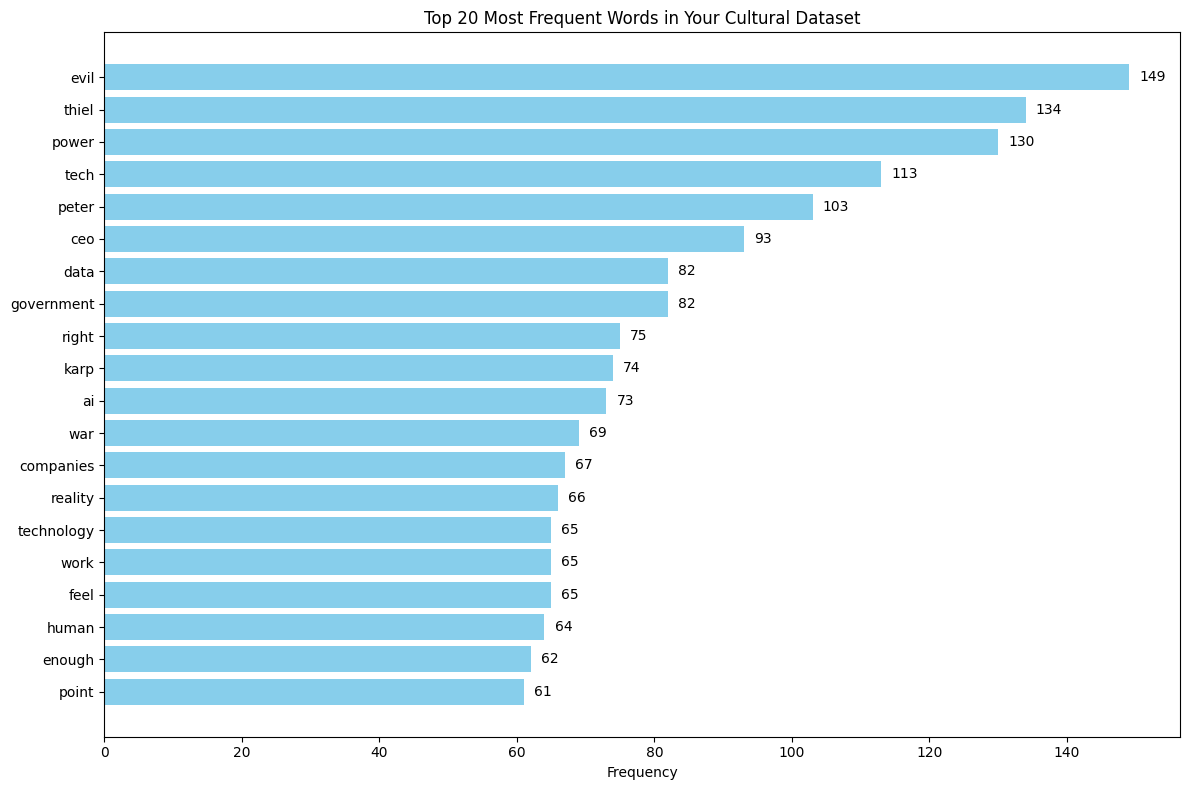

📊 Term frequency visualization complete!


In [41]:
# Create visualization of top words
words = [word for word, count in top_words]
counts = [count for word, count in top_words]

plt.figure(figsize=(12, 8))
plt.barh(range(len(words)), counts, color='skyblue')
plt.yticks(range(len(words)), words)
plt.xlabel('Frequency')
plt.title(f'Top {len(words)} Most Frequent Words in Your Cultural Dataset')
plt.gca().invert_yaxis()  # Put highest frequency at top

# Add count labels on bars
for i, count in enumerate(counts):
    plt.text(count + max(counts)*0.01, i, str(count), va='center')

plt.tight_layout()
plt.show()

print("📊 Term frequency visualization complete!")

In [17]:
# New visualization. I am curious if the word "us" is including the actual word, and the US as a country (mostl likely)

### 📝 Term Frequency Reflection:

Upon seeing this term frequency visual, I'm interested to add some more stopwords going forward. Words like the actual company name "Palantir" or words like "people" are not very significant/ descriptive words.


In [18]:
# short term frequency analysis for palantir comments


---

## Step 4: Sentiment Analysis with VADER
*Building on VADER CodeAlong Skills*

Now let's analyze the emotional tone of your cultural texts using VADER, focusing on the compound sentiment scores.

In [14]:
# Install and import VADER
!pip install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

print("✅ VADER installed and ready for sentiment analysis!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.5 MB/s eta 0:00:00
✅ VADER installed and ready for sentiment analysis!


### Technical Checkpoint 3: VADER Installation/Import

In [16]:
# Checkpoint 3: VADER setup
test_text = "!"
test_result = analyzer.polarity_scores(test_text)
print(f"Test text: {test_text}")
print(f"VADER result: {test_result}")
# Should see: {'neg': 0.0, 'neu': 0.323, 'pos': 0.677, 'compound': 0.6588} (or similar)

Test text: !
VADER result: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}


In [17]:
# Apply sentiment analysis to your entire dataset
def get_sentiment_score(text):
    """Get compound sentiment score for a text"""
    scores = analyzer.polarity_scores(text)
    return scores['compound']

# Apply sentiment analysis to your entire dataset
df['sentiment_score'] = df['clean_text_sentiment'].apply(get_sentiment_score) # Fill in: what function?

print("✅ Sentiment analysis complete for entire dataset!")
print(f"\nSentiment score range: {df['sentiment_score'].min():.3f} to {df['sentiment_score'].max():.3f}")
print(f"Average sentiment: {df['sentiment_score'].mean():.3f}")

✅ Sentiment analysis complete for entire dataset!

Sentiment score range: -0.952 to 0.993
Average sentiment: -0.010


In [22]:
# ok, so this is basicallt neutral, slightly leaning negative. I think that there is sarcasm skewing the results to be more positive


In [18]:
# Analyze sentiment patterns in your data
print("🎭 SENTIMENT ANALYSIS SUMMARY")
print("=" * 35)

# Basic statistics
print(f"Total entries analyzed: {len(df)}")
print(f"Average sentiment: {df['sentiment_score'].mean():.3f}")
print(f"Most positive entry: {df['sentiment_score'].max():.3f}")
print(f"Most negative entry: {df['sentiment_score'].min():.3f}")
print(f"Standard deviation: {df['sentiment_score'].std():.3f}")

# Categorize sentiments
positive = len(df[df['sentiment_score'] > 0.1])
neutral = len(df[(df['sentiment_score'] >= -0.1) & (df['sentiment_score'] <= 0.1)])
negative = len(df[df['sentiment_score'] < -0.1])

print(f"\nSentiment distribution:")
print(f"Positive (>0.1): {positive} ({positive/len(df)*100:.1f}%)")
print(f"Neutral (-0.1 to 0.1): {neutral} ({neutral/len(df)*100:.1f}%)")
print(f"Negative (<-0.1): {negative} ({negative/len(df)*100:.1f}%)")

🎭 SENTIMENT ANALYSIS SUMMARY
Total entries analyzed: 2131
Average sentiment: -0.010
Most positive entry: 0.993
Most negative entry: -0.952
Standard deviation: 0.522

Sentiment distribution:
Positive (>0.1): 829 (38.9%)
Neutral (-0.1 to 0.1): 450 (21.1%)
Negative (<-0.1): 852 (40.0%)


In [21]:
# Create sentiment categories based on compound score
def categorize_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_category'] = df['sentiment_score'].apply(categorize_sentiment)

# Compute the average compound score for each category
avg_scores = df.groupby('sentiment_category')['sentiment_score'].mean().round(3)
print(avg_scores)


sentiment_category
Negative   -0.526
Neutral    -0.001
Positive    0.523
Name: sentiment_score, dtype: float64


In [19]:
# Find most positive and negative examples
most_positive = df.loc[df['sentiment_score'].idxmax()]
most_negative = df.loc[df['sentiment_score'].idxmin()]

print(f"📈 MOST POSITIVE ENTRY (score: {most_positive['sentiment_score']:.3f}):")
print(f"Text: {most_positive['clean_text_sentiment'][:200]}...")
print()
print(f"📉 MOST NEGATIVE ENTRY (score: {most_negative['sentiment_score']:.3f}):")
print(f"Text: {most_negative['clean_text_sentiment'][:200]}...")

📈 MOST POSITIVE ENTRY (score: 0.993):
Text: Damn guys, this is really well done! You really met the moment on this one.

I appreciate the documentary approach. I think you guys got a certain style down - solid clean shots, well paced (not too m...

📉 MOST NEGATIVE ENTRY (score: -0.952):
Text: The alignment problem with AI isn't SOLVED! But they still have had weapon drones and other uses of weapons to kill civilians in Gaza. 

All the professors of AI and really credible professor's and su...


In [25]:
# so it seems that the most positive review isn't positively speaking on palantir, but on the video production.

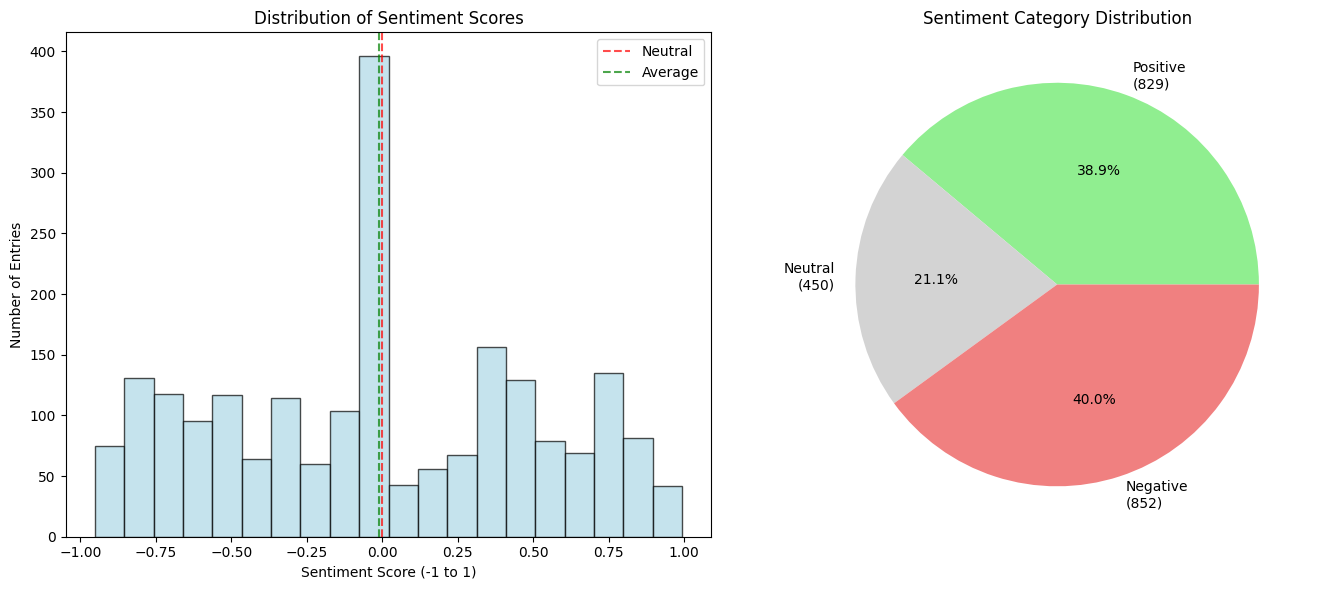

📊 Sentiment visualizations complete!


In [20]:
# Create sentiment visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sentiment distribution histogram
axes[0].hist(df['sentiment_score'], bins=20, color='lightblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Distribution of Sentiment Scores')
axes[0].set_xlabel('Sentiment Score (-1 to 1)')
axes[0].set_ylabel('Number of Entries')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.7, label='Neutral')
axes[0].axvline(df['sentiment_score'].mean(), color='green', linestyle='--', alpha=0.7, label='Average')
axes[0].legend()

# Sentiment categories pie chart
sentiment_counts = [positive, neutral, negative]
sentiment_labels = [f'Positive\n({positive})', f'Neutral\n({neutral})', f'Negative\n({negative})']
colors = ['lightgreen', 'lightgray', 'lightcoral']

axes[1].pie(sentiment_counts, labels=sentiment_labels, colors=colors, autopct='%1.1f%%')
axes[1].set_title('Sentiment Category Distribution')

plt.tight_layout()
plt.show()

print("📊 Sentiment visualizations complete!")

### Human vs. Automated Sentiment Check

Let's test VADER's accuracy by comparing it to your human judgment:

---

## Step 5: Integration and Critical Analysis
*Connecting Term Frequency and Sentiment Insights*

Now let's explore how your term frequency and sentiment findings work together to reveal deeper patterns in your cultural data.

In [48]:
# Analyze word frequency in positive vs. negative entries
positive_entries = df[df['sentiment_score'] > 0.1]
negative_entries = df[df['sentiment_score'] < -0.1]

print("🔍 COMPARING WORDS IN POSITIVE vs. NEGATIVE ENTRIES")
print("=" * 55)

# Get top words from positive entries
positive_words = []
for word_list in positive_entries['meaningful_words']:
    positive_words.extend(word_list)
positive_freq = Counter(positive_words)

# Get top words from negative entries
negative_words = []
for word_list in negative_entries['meaningful_words']:
    negative_words.extend(word_list)
negative_freq = Counter(negative_words)

print(f"Top 10 words in POSITIVE entries ({len(positive_entries)} entries):")
for word, count in positive_freq.most_common(10):
    print(f"  {word:<15} ({count} times)")

print(f"\nTop 10 words in NEGATIVE entries ({len(negative_entries)} entries):")
for word, count in negative_freq.most_common(10):
    print(f"  {word:<15} ({count} times)")

🔍 COMPARING WORDS IN POSITIVE vs. NEGATIVE ENTRIES
Top 10 words in POSITIVE entries (829 entries):
  thiel           (53 times)
  power           (45 times)
  work            (45 times)
  m               (44 times)
  companies       (43 times)
  ceo             (41 times)
  enough          (40 times)
  tech            (40 times)
  sounds          (39 times)
  reality         (38 times)

Top 10 words in NEGATIVE entries (852 entries):
  evil            (116 times)
  tech            (63 times)
  thiel           (61 times)
  war             (53 times)
  peter           (43 times)
  power           (40 times)
  scary           (40 times)
  karp            (38 times)
  dangerous       (38 times)
  ceo             (37 times)


In [28]:
# looks like these positive words are not necessarily very positive.. but the negative entries are more negative.


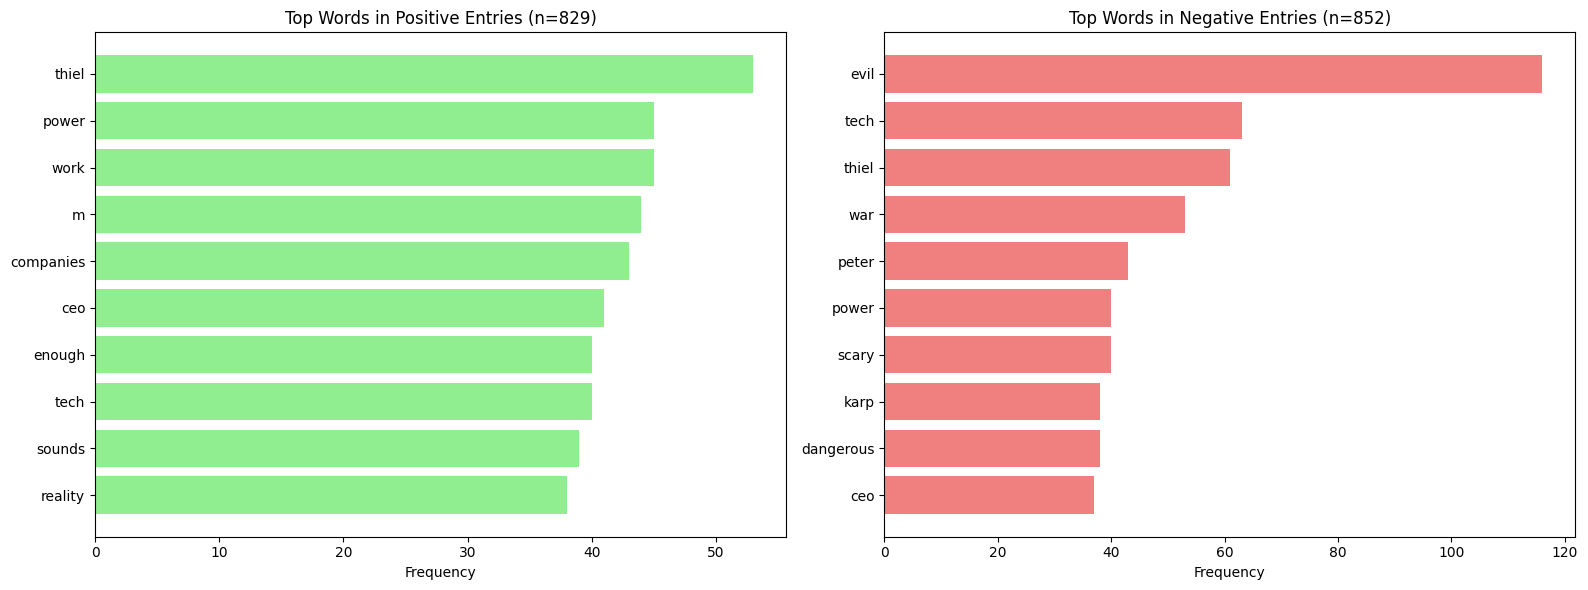

In [49]:
# Create comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive words
pos_words = [word for word, count in positive_freq.most_common(10)]
pos_counts = [count for word, count in positive_freq.most_common(10)]

axes[0].barh(range(len(pos_words)), pos_counts, color='lightgreen')
axes[0].set_yticks(range(len(pos_words)))
axes[0].set_yticklabels(pos_words)
axes[0].set_title(f'Top Words in Positive Entries (n={len(positive_entries)})')
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()

# Negative words
neg_words = [word for word, count in negative_freq.most_common(10)]
neg_counts = [count for word, count in negative_freq.most_common(10)]

axes[1].barh(range(len(neg_words)), neg_counts, color='lightcoral')
axes[1].set_yticks(range(len(neg_words)))
axes[1].set_yticklabels(neg_words)
axes[1].set_title(f'Top Words in Negative Entries (n={len(negative_entries)})')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [50]:
# Save your cleaned dataset
output_filename = 'PLTR_comments_clean'  # Replace LASTNAME with your actual last name
df.to_csv(output_filename, index=False)

print(f"✅ Cleaned dataset saved as: {output_filename}")
print(f"\nDataset summary:")
print(f"- Total entries: {len(df)}")
print(f"- Columns: {df.columns.tolist()}")
print(f"- Average sentiment score: {df['sentiment_score'].mean():.3f}")
print(f"- Most frequent word: '{top_words[0][0]}' ({top_words[0][1]} times)")

✅ Cleaned dataset saved as: PLTR_comments_clean

Dataset summary:
- Total entries: 2131
- Columns: ['recency', 'comment_link', 'comment', 'number_of_likes', 'number_of_replies', 'clean_text_sentiment', 'words', 'meaningful_words', 'sentiment_score']
- Average sentiment score: -0.010
- Most frequent word: 'evil' (149 times)


In [1]:
# STEP 1: Install Required Libraries
# Run this cell ONCE, then follow the instructions below

print("📦 Installing dependencies (this takes ~30 seconds)...")
print("=" * 60)

# Uninstall conflicting packages
!pip uninstall -y numpy pandas scipy

# Install compatible versions together
!pip install -q numpy==1.26.4 pandas==2.2.2 scipy==1.13.1

# Install gensim and nltk
!pip install -q gensim==4.3.3 nltk

print("\n" + "=" * 60)
print("✅ Installation complete!")
print("=" * 60)
print("\n🔄 🔄 🔄 STOP! MANDATORY NEXT STEP 🔄 🔄 🔄")
print("\nYou MUST restart the runtime before continuing:")
print("   1. Click 'Runtime' in the menu bar above")
print("   2. Select 'Restart runtime'")
print("   3. When prompted, click 'Yes' to confirm")
print("   4. Then run the NEXT cell to import libraries")
print("\n⚠️  Do NOT skip this step or you will get errors!")
print("=" * 60)

📦 Installing dependencies (this takes ~30 seconds)...
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.13.1
Uninstalling scipy-1.13.1:
  Successfully uninstalled scipy-1.13.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.1 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 

In [2]:
# STEP 2: Import Libraries
# Run this cell ONLY AFTER restarting runtime

print("📚 Importing libraries...")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

import gensim
from gensim import corpora
from gensim.models import LdaModel
from nltk.stem import WordNetLemmatizer

import nltk
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("=" * 60)
print("✅ All libraries loaded and ready!")
print("=" * 60)
print(f"NumPy version: {np.__version__}")
print(f"Gensim version: {gensim.__version__}")
print("\n🎉 You're ready to proceed with the assignment!")

📚 Importing libraries...
✅ All libraries loaded and ready!
NumPy version: 1.26.4
Gensim version: 4.3.3

🎉 You're ready to proceed with the assignment!


In [3]:
# Load your cleaned dataset from HW4-1
# If you're in Google Colab, upload your file first:
# from google.colab import files
# uploaded = files.upload()

# Load your HW4-1 cleaned data
df = pd.read_csv('/content/PLTR_comments_clean')

print(f"✅ Dataset loaded successfully!")
print(f"Dataset contains {len(df)} items")
print(f"\nColumns available: {df.columns.tolist()}")

✅ Dataset loaded successfully!
Dataset contains 2131 items

Columns available: ['recency', 'comment_link', 'comment', 'number_of_likes', 'number_of_replies', 'clean_text_sentiment', 'words', 'meaningful_words', 'sentiment_score']


In [4]:
# Verify your data is ready
print("📊 DATASET SUMMARY FROM HW4-1")
print("=" * 40)
print(f"Total entries: {len(df)}")
print(f"Average sentiment score: {df['sentiment_score'].mean():.3f}")
print(f"\nFirst few entries:")
df.head()

📊 DATASET SUMMARY FROM HW4-1
Total entries: 2131
Average sentiment score: -0.010

First few entries:


,recency,comment_link,comment,number_of_likes,number_of_replies,clean_text_sentiment,words,meaningful_words,sentiment_score
0,3 months ago,https://www.youtube.com/watch?v=DZ95Gmvg_D4&lc...,The worst thing in the world is that we have n...,5.3K,122 replies,The worst thing in the world is that we have n...,"['the', 'worst', 'thing', 'in', 'the', 'world'...","['worst', 'comic', 'book', 'heroes', 'many', '...",-0.8442
1,2 months ago,https://www.youtube.com/watch?v=DZ95Gmvg_D4&lc...,CEO is scarily unhinged.. You can tell he's on...,1.8K,36 replies,CEO is scarily unhinged.. You can tell he's on...,"['ceo', 'is', 'scarily', 'unhinged', 'you', 'c...","['ceo', 'scarily', 'unhinged', 'tell', 'seriou...",-0.0772
2,6 months ago,https://www.youtube.com/watch?v=DZ95Gmvg_D4&lc...,We are not outnumbered. We're out-organized.,11K,214 replies,We are not outnumbered. We're out-organized.,"['we', 'are', 'not', 'outnumbered', 'we', 're'...","['outnumbered', 'organized']",0.0000
3,1 month ago,https://www.youtube.com/watch?v=DZ95Gmvg_D4&lc...,"Why do movies, comics, and video games always ...",728,17 replies,"Why do movies, comics, and video games always ...","['why', 'do', 'movies', 'comics', 'and', 'vide...","['movies', 'comics', 'games', 'always', 'show'...",0.7650
4,5 months ago,https://www.youtube.com/watch?v=DZ95Gmvg_D4&lc...,"""Bad times are good for Palantir"" says the CEO...",2.4K,16 replies,"""Bad times are good for Palantir"" says the CEO...","['bad', 'times', 'are', 'good', 'for', 'palant...","['says', 'ceo', 'tells', 'government', 'whether']",0.3182


In [5]:
# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

def preprocess_for_topics(text):
    """
    Aggressive text preprocessing for topic modeling:
    - Lowercase
    - Remove punctuation
    - Remove stopwords
    - Lemmatize (reduce to base form)
    """
    if pd.isna(text):
        return []

    # Convert to lowercase
    text = str(text).lower()

    # Remove punctuation and split into words
    words = re.findall(r'\b[a-z]+\b', text)

    # Remove stopwords and short words (< 3 characters)
    words = [word for word in words if word not in stopwords and len(word) >= 3]

    # Lemmatize words (reduce to base form)
    words = [lemmatizer.lemmatize(word) for word in words]

    return words

print("✅ Preprocessing function ready")

✅ Preprocessing function ready


In [8]:
# Test preprocessing on one text
text_column = 'comment'  # Fill in your text column name from HW4-1

sample_text = df[text_column].iloc[0]
processed = preprocess_for_topics(sample_text)

print("Text Preprocessing Test:")
print(f"Original: {sample_text[:150]}...")
print(f"\nProcessed words: {processed}")
print(f"\nNotice: lowercase, no punctuation, lemmatized, stopwords removed")

Text Preprocessing Test:
Original: The worst thing in the world is that we have no comic book heroes but we have so many comic book villains...

Processed words: ['worst', 'comic', 'book', 'hero', 'many', 'comic', 'book', 'villain']

Notice: lowercase, no punctuation, lemmatized, stopwords removed


In [ ]:
# chose to rerun the stopwords at the top of this file

In [9]:
# Apply preprocessing to entire dataset
df['processed_for_topics'] = df[text_column].apply(preprocess_for_topics)

print("✅ Preprocessing complete!")
print(f"\nProcessed {len(df)} documents")
print(f"\nExample processed documents:")
for i in range(3):
    print(f"{i+1}. {df['processed_for_topics'].iloc[i][:10]}...")

✅ Preprocessing complete!

Processed 2131 documents

Example processed documents:
1. ['worst', 'comic', 'book', 'hero', 'many', 'comic', 'book', 'villain']...
2. ['ceo', 'scarily', 'unhinged', 'tell', 'serious', 'power', 'trip']...
3. ['outnumbered', 'organized']...


In [10]:
# Checkpoint: Verify data is ready for topic modeling
doc_lengths = [len(doc) for doc in df['processed_for_topics']]
avg_length = np.mean(doc_lengths)
all_words = [word for doc in df['processed_for_topics'] for word in doc]
vocab_size = len(set(all_words))

print("📊 DATA PREPARATION CHECK")
print("=" * 40)
print(f"Number of documents: {len(df)}")
print(f"Vocabulary size: {vocab_size}")
print(f"Average document length: {avg_length:.1f} words")
print(f"Shortest document: {min(doc_lengths)} words")
print(f"Longest document: {max(doc_lengths)} words")

if avg_length < 10:
    print("\n⚠️ WARNING: Average document length is very short. Topic modeling may struggle.")
if vocab_size < 100:
    print("\n⚠️ WARNING: Vocabulary size is small. Consider reducing custom stopwords.")

📊 DATA PREPARATION CHECK
Number of documents: 2131
Vocabulary size: 2712
Average document length: 10.9 words
Shortest document: 0 words
Longest document: 254 words


In [11]:
# Create Gensim dictionary and corpus
dictionary = corpora.Dictionary(df['processed_for_topics'])
corpus = [dictionary.doc2bow(doc) for doc in df['processed_for_topics']]

print("📖 Dictionary and corpus created!")
print(f"Total unique words in dictionary: {len(dictionary)}")
print(f"Total documents in corpus: {len(corpus)}")
print(f"\nExample word-to-ID mappings:")
for i, (word_id, word) in enumerate(list(dictionary.items())[:10]):
    print(f"  ID {word_id}: {word}")

📖 Dictionary and corpus created!
Total unique words in dictionary: 2712
Total documents in corpus: 2131

Example word-to-ID mappings:
  ID 0: book
  ID 1: comic
  ID 2: hero
  ID 3: many
  ID 4: villain
  ID 5: worst
  ID 6: ceo
  ID 7: power
  ID 8: scarily
  ID 9: serious


In [12]:
# Experiment: Try different numbers of topics
def train_and_display_topics(corpus, dictionary, num_topics):
    """
    Train an LDA model and display discovered topics
    """
    print(f"\n{'='*60}")
    print(f"MODEL WITH {num_topics} TOPICS")
    print(f"{'='*60}")

    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=15,
        alpha='auto',
        eta='auto'
    )

    for idx in range(num_topics):
        words = model.show_topic(idx, 10)
        word_list = [word for word, prob in words]
        print(f"Topic {idx}: {', '.join(word_list)}")

    return model

# Try 3, 5, and 7 topics
print("🧪 EXPERIMENTING WITH DIFFERENT NUMBERS OF TOPICS")
print("Watch how topics change as we increase the number...\n")

model_3 = train_and_display_topics(corpus, dictionary, 3)
model_5 = train_and_display_topics(corpus, dictionary, 5)
model_7 = train_and_display_topics(corpus, dictionary, 7)

🧪 EXPERIMENTING WITH DIFFERENT NUMBERS OF TOPICS
Watch how topics change as we increase the number...


MODEL WITH 3 TOPICS
Topic 0: evil, system, right, life, getting, child, hide, information, anymore, data
Topic 1: sound, tech, look, alex, karp, ceo, report, level, future, solution
Topic 2: company, let, got, government, sure, problem, tech, war, thiel, ceo

MODEL WITH 5 TOPICS
Topic 0: evil, ceo, right, tech, government, hide, anymore, wrong, data, technology
Topic 1: tech, sound, alex, ceo, solution, ever, ultimate, look, doesn, report
Topic 2: sure, control, kid, war, got, already, service, government, data, using
Topic 3: system, let, evil, feel, seems, look, sauron, got, govt, healthcare
Topic 4: thiel, year, child, let, problem, everyone, power, karp, right, life

MODEL WITH 7 TOPICS
Topic 0: evil, ceo, hide, anymore, right, look, kill, eye, former, sauron
Topic 1: sound, minority, report, solution, doesn, everything, ceo, without, anything, silicon
Topic 2: problem, control, 

In [13]:
# Train your final model with your chosen number of topics
num_topics = 7  # Fill in your chosen number (3, 5, or 7)

print(f"🤖 Training final LDA model with {num_topics} topics...\n")

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=20,  # More passes for better final model
    alpha='auto',
    eta='auto'
)

print("✅ Final model training complete!\n")
print("🎯 YOUR DISCOVERED TOPICS")
print("=" * 70)

for idx in range(num_topics):
    words = lda_model.show_topic(idx, 10)
    word_list = [word for word, prob in words]
    print(f"\nTopic {idx}: {', '.join(word_list)}")
    print(f"Your interpretation/label: 7 topics")

🤖 Training final LDA model with 7 topics...

✅ Final model training complete!

🎯 YOUR DISCOVERED TOPICS

Topic 0: evil, ceo, hide, anymore, right, look, kill, eye, former, privacy
Your interpretation/label: 7 topics

Topic 1: sound, minority, report, solution, doesn, everything, ceo, without, anything, silicon
Your interpretation/label: 7 topics

Topic 2: problem, control, got, kid, sure, already, book, human, day, family
Your interpretation/label: 7 topics

Topic 3: system, war, full, rubber, got, money, watching, huge, stop, imagine
Your interpretation/label: 7 topics

Topic 4: thiel, power, child, everyone, right, enough, liberty, need, technology, information
Your interpretation/label: 7 topics

Topic 5: government, data, tech, alex, actually, year, getting, elite, skynet, around
Your interpretation/label: 7 topics

Topic 6: tech, let, life, sauron, act, peace, help, work, feel, rest
Your interpretation/label: 7 topics


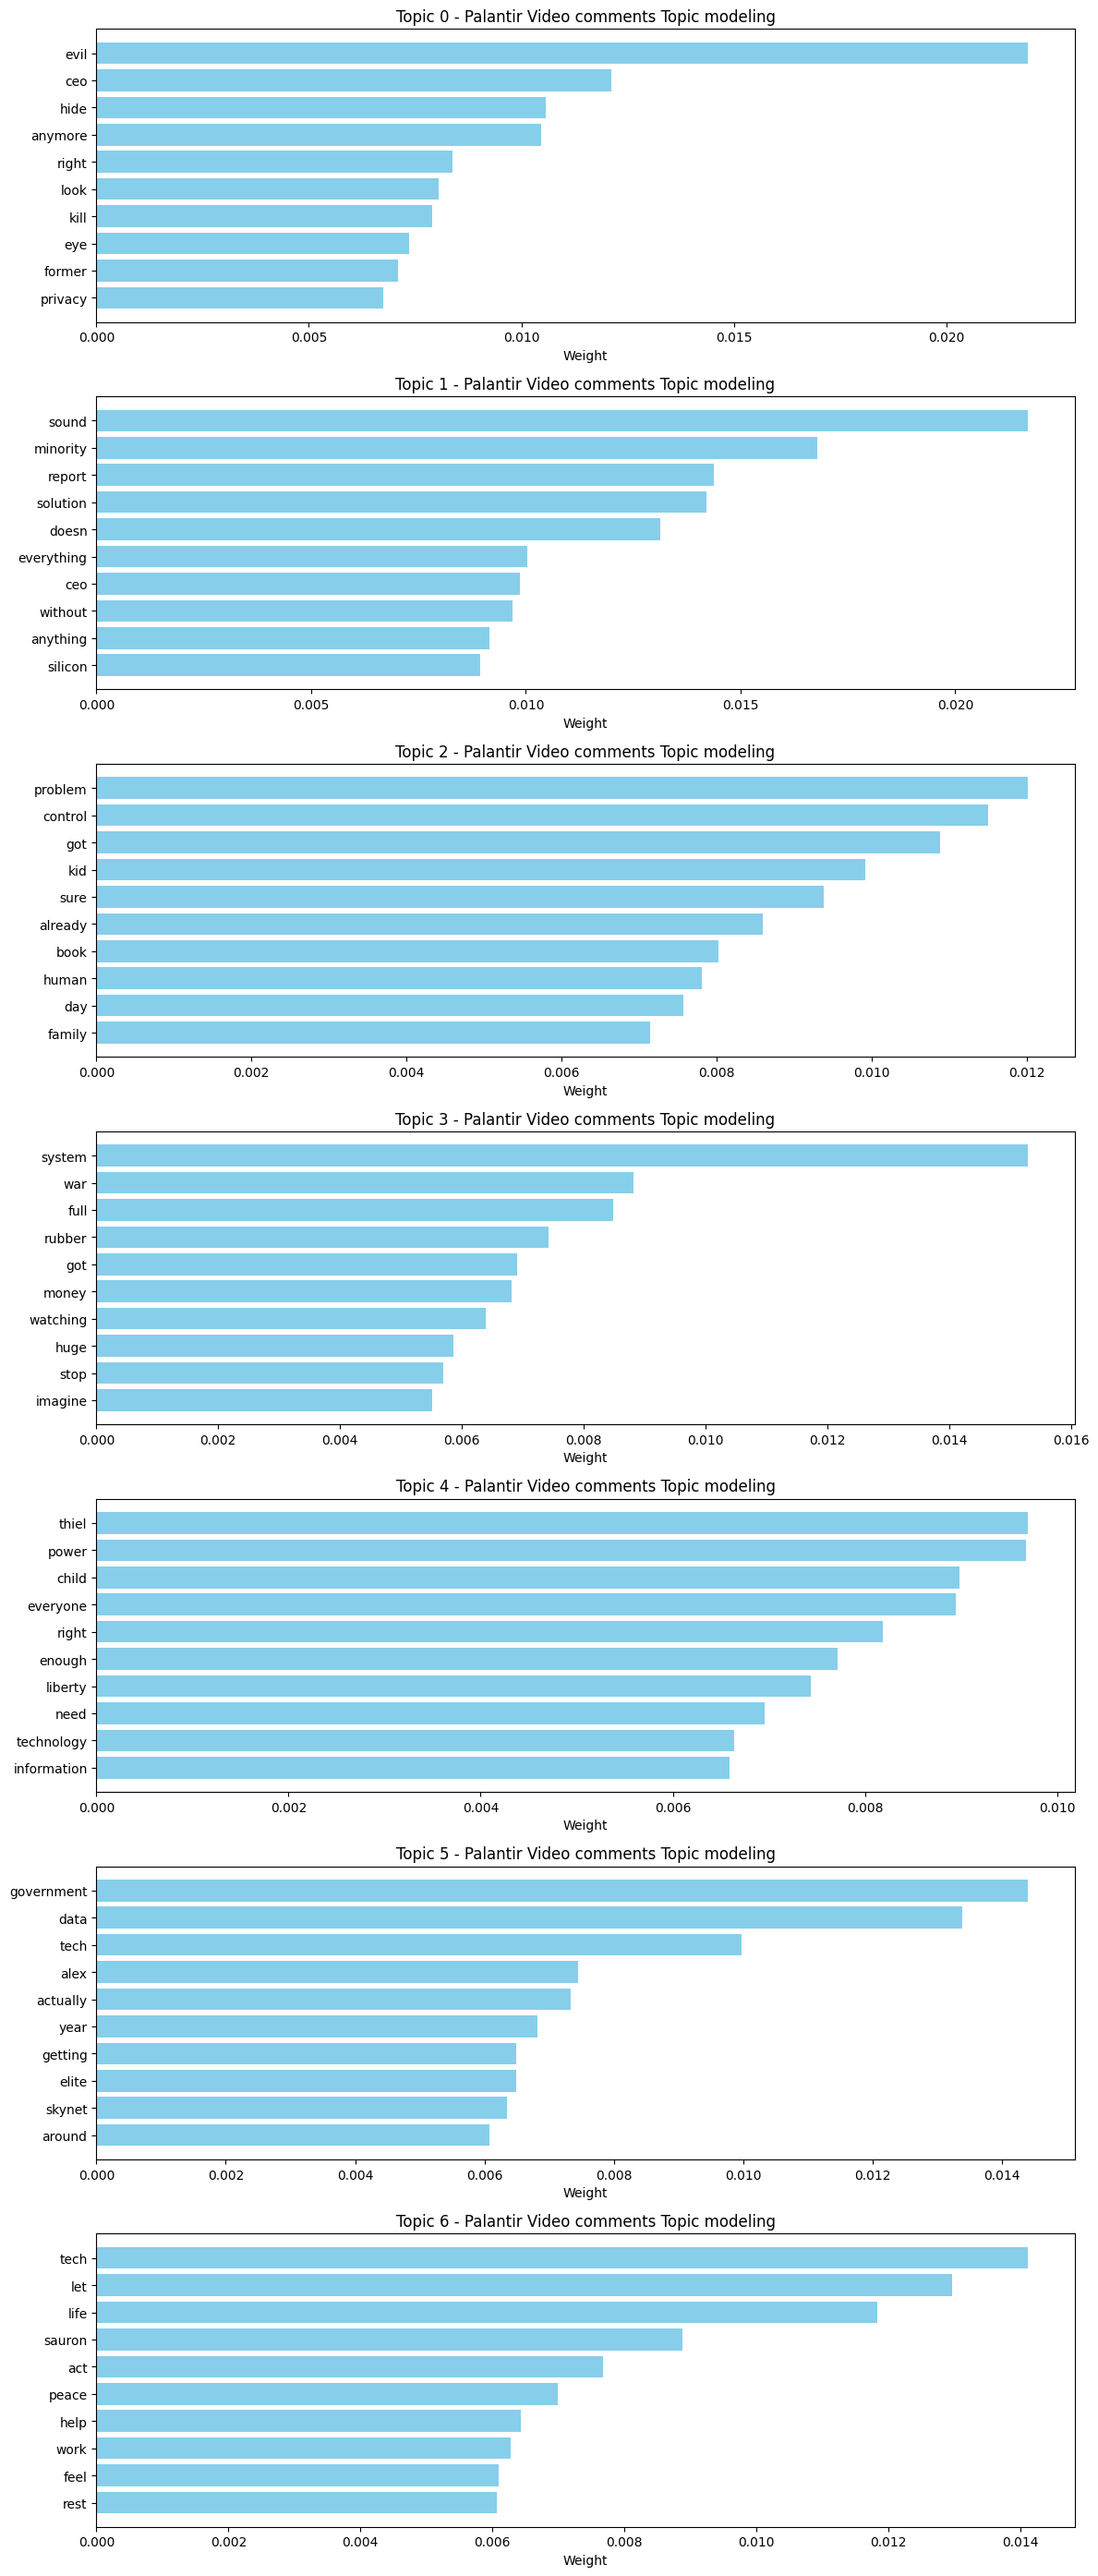

📊 Topic visualizations complete!


In [16]:
# Visualize your topics
import matplotlib.pyplot as plt

fig, axes = plt.subplots(num_topics, 1, figsize=(12, 4*num_topics))

if num_topics == 1:
    axes = [axes]

for idx in range(num_topics):
    words_weights = lda_model.show_topic(idx, 10)
    words = [word for word, weight in words_weights]
    weights = [weight for word, weight in words_weights]

    axes[idx].barh(range(len(words)), weights, color='skyblue')
    axes[idx].set_yticks(range(len(words)))
    axes[idx].set_yticklabels(words)
    axes[idx].set_xlabel('Weight')
    axes[idx].set_title(f'Topic {idx} - Palantir Video comments Topic modeling')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

print("📊 Topic visualizations complete!")

In [17]:
# Get dominant topic for each document
def get_document_topics(lda_model, corpus):
    """
    Get dominant topic assignment for each document
    """
    topic_assignments = []

    for doc in corpus:
        topic_dist = lda_model.get_document_topics(doc)
        if topic_dist:  # Check if not empty
            dominant_topic = max(topic_dist, key=lambda x: x[1])
            topic_assignments.append({
                'topic_num': dominant_topic[0],
                'topic_prob': round(dominant_topic[1], 3)
            })
        else:
            topic_assignments.append({
                'topic_num': -1,
                'topic_prob': 0.0
            })

    return topic_assignments

# Get topic assignments
topic_info = get_document_topics(lda_model, corpus)
df['dominant_topic'] = [t['topic_num'] for t in topic_info]
df['topic_probability'] = [t['topic_prob'] for t in topic_info]

print("✅ Topic assignments complete!")
print(f"\nTopic distribution across documents:")
print(df['dominant_topic'].value_counts().sort_index())

✅ Topic assignments complete!

Topic distribution across documents:
dominant_topic
0    382
1    275
2    206
3    281
4    402
5    292
6    293
Name: count, dtype: int64


In [18]:
# Sample documents from each topic for validation
print("🔍 DOCUMENT-TOPIC VALIDATION CHECK")
print("=" * 70)
print("For each topic, read sample documents and assess if the assignment makes sense:\n")

for topic_num in range(num_topics):
    print(f"\n📌 TOPIC {topic_num}")
    print("=" * 50)

    # Get top words for this topic
    topic_words = lda_model.show_topic(topic_num, 8)
    word_list = [word for word, prob in topic_words]
    print(f"Keywords: {', '.join(word_list)}")

    # Get sample documents from this topic
    topic_docs = df[df['dominant_topic'] == topic_num]

    if len(topic_docs) == 0:
        print("No documents assigned to this topic.")
        continue

    print(f"\nDocuments in this topic: {len(topic_docs)}")
    print(f"\nSample documents (read and assess if topic assignment makes sense):\n")

    for i, (idx, row) in enumerate(topic_docs.head(3).iterrows(), 1):
        print(f"  {i}. {row[text_column][:150]}...")
        print(f"     Probability: {row['topic_probability']:.3f}")
        print()

🔍 DOCUMENT-TOPIC VALIDATION CHECK
For each topic, read sample documents and assess if the assignment makes sense:


📌 TOPIC 0
Keywords: evil, ceo, hide, anymore, right, look, kill, eye

Documents in this topic: 382

Sample documents (read and assess if topic assignment makes sense):

  1. "Bad times are good for Palantir" says the CEO of a company that tells government whether the times are good....
     Probability: 0.953

  2. The way that palantir ceo speaks, it sounds like that company has too much at stake for peace to be allowable...
     Probability: 0.609

  3. Social engineering meets political science meets monetary greed......
     Probability: 0.970


📌 TOPIC 1
Keywords: sound, minority, report, solution, doesn, everything, ceo, without

Documents in this topic: 275

Sample documents (read and assess if topic assignment makes sense):

  1. "We do well in hard times, so we like hard times." How to call yourself a vulture without saying it....
     Probability: 0.960

  2. "W

In [19]:
# Analyze sentiment patterns within each topic
print("📊 SENTIMENT BY TOPIC ANALYSIS")
print("=" * 50)

for topic_num in range(num_topics):
    topic_docs = df[df['dominant_topic'] == topic_num]

    if len(topic_docs) == 0:
        continue

    avg_sentiment = topic_docs['sentiment_score'].mean()

    # Get topic keywords
    topic_words = lda_model.show_topic(topic_num, 5)
    word_list = [word for word, prob in topic_words]

    print(f"\nTopic {topic_num}: {', '.join(word_list)}")
    print(f"  Documents: {len(topic_docs)}")
    print(f"  Average sentiment: {avg_sentiment:.3f}")
    print(f"  Sentiment range: {topic_docs['sentiment_score'].min():.3f} to {topic_docs['sentiment_score'].max():.3f}")

📊 SENTIMENT BY TOPIC ANALYSIS

Topic 0: evil, ceo, hide, anymore, right
  Documents: 382
  Average sentiment: -0.092
  Sentiment range: -0.952 to 0.944

Topic 1: sound, minority, report, solution, doesn
  Documents: 275
  Average sentiment: 0.172
  Sentiment range: -0.941 to 0.984

Topic 2: problem, control, got, kid, sure
  Documents: 206
  Average sentiment: -0.035
  Sentiment range: -0.875 to 0.976

Topic 3: system, war, full, rubber, got
  Documents: 281
  Average sentiment: -0.031
  Sentiment range: -0.862 to 0.993

Topic 4: thiel, power, child, everyone, right
  Documents: 402
  Average sentiment: -0.009
  Sentiment range: -0.915 to 0.905

Topic 5: government, data, tech, alex, actually
  Documents: 292
  Average sentiment: -0.028
  Sentiment range: -0.945 to 0.851

Topic 6: tech, let, life, sauron, act
  Documents: 293
  Average sentiment: -0.020
  Sentiment range: -0.933 to 0.921


/tmp/ipython-input-278388074.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(topic_sentiment_data, labels=[f'Topic {i}' for i in range(num_topics)])


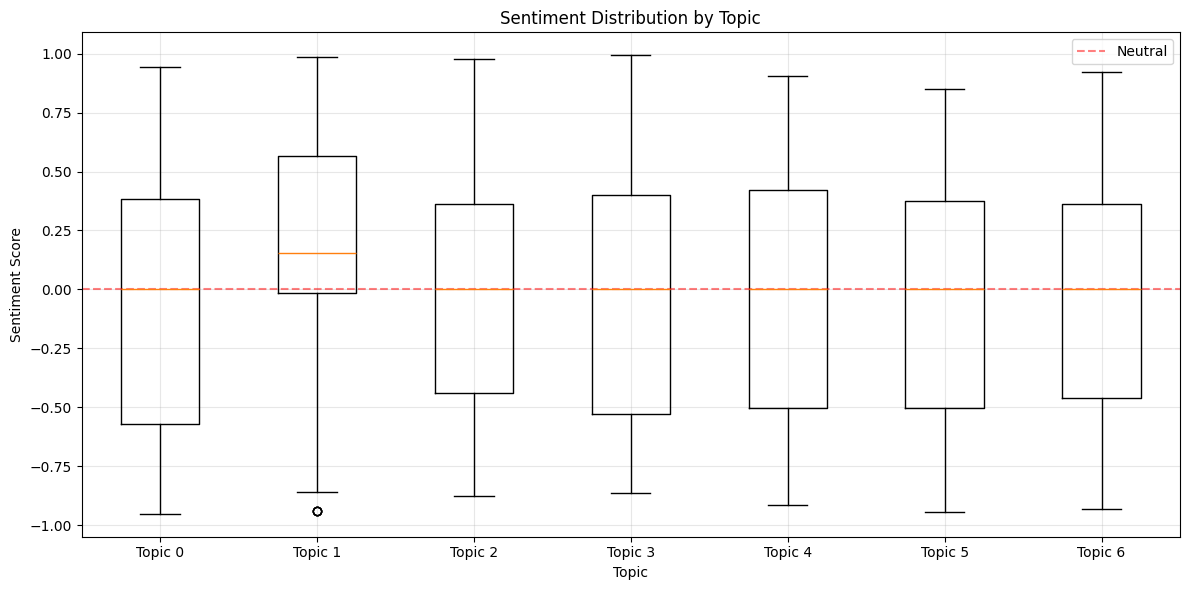

📊 Sentiment by topic visualization complete!


In [20]:
# Visualize sentiment distribution by topic
fig, ax = plt.subplots(figsize=(12, 6))

# Create box plot of sentiment scores by topic
topic_sentiment_data = [df[df['dominant_topic'] == i]['sentiment_score'].values
                        for i in range(num_topics)]

ax.boxplot(topic_sentiment_data, labels=[f'Topic {i}' for i in range(num_topics)])
ax.set_xlabel('Topic')
ax.set_ylabel('Sentiment Score')
ax.set_title('Sentiment Distribution by Topic')
ax.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Neutral')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Sentiment by topic visualization complete!")

In [21]:
# Create comprehensive summary
print("📋 COMPLETE ANALYTICAL SUMMARY")
print("=" * 60)
print(f"\nDataset: {len(df)} documents")
print(f"\n1️⃣ TERM FREQUENCY (from HW4-1):")
print(f"   Vocabulary size: {len(dictionary)} unique words")
print(f" great, like, best, entertaining, watch, good, really, acting, funny, amazing  ")

print(f"\n2️⃣ SENTIMENT ANALYSIS (from HW4-1):")
print(f"   Average sentiment: {df['sentiment_score'].mean():.3f}")
print(f"   Positive: {len(df[df['sentiment_score'] > 0.1])} ({len(df[df['sentiment_score'] > 0.1])/len(df)*100:.1f}%)")
print(f"   Neutral: {len(df[(df['sentiment_score'] >= -0.1) & (df['sentiment_score'] <= 0.1)])} ({len(df[(df['sentiment_score'] >= -0.1) & (df['sentiment_score'] <= 0.1)])/len(df)*100:.1f}%)")
print(f"   Negative: {len(df[df['sentiment_score'] < -0.1])} ({len(df[df['sentiment_score'] < -0.1])/len(df)*100:.1f}%)")

print(f"\n3️⃣ TOPIC MODELING (HW4-2):")
print(f"   Number of topics: {num_topics}")
for topic_num in range(num_topics):
    topic_docs = df[df['dominant_topic'] == topic_num]
    if len(topic_docs) > 0:
        topic_words = lda_model.show_topic(topic_num, 3)
        word_list = [word for word, prob in topic_words]
        print(f"   Topic {topic_num} ({len(topic_docs)} docs, avg sentiment {topic_docs['sentiment_score'].mean():.2f}): {', '.join(word_list)}")

📋 COMPLETE ANALYTICAL SUMMARY

Dataset: 2131 documents

1️⃣ TERM FREQUENCY (from HW4-1):
   Vocabulary size: 2712 unique words
 great, like, best, entertaining, watch, good, really, acting, funny, amazing  

2️⃣ SENTIMENT ANALYSIS (from HW4-1):
   Average sentiment: -0.010
   Positive: 829 (38.9%)
   Neutral: 450 (21.1%)
   Negative: 852 (40.0%)

3️⃣ TOPIC MODELING (HW4-2):
   Number of topics: 7
   Topic 0 (382 docs, avg sentiment -0.09): evil, ceo, hide
   Topic 1 (275 docs, avg sentiment 0.17): sound, minority, report
   Topic 2 (206 docs, avg sentiment -0.04): problem, control, got
   Topic 3 (281 docs, avg sentiment -0.03): system, war, full
   Topic 4 (402 docs, avg sentiment -0.01): thiel, power, child
   Topic 5 (292 docs, avg sentiment -0.03): government, data, tech
   Topic 6 (293 docs, avg sentiment -0.02): tech, let, life


In [22]:
# Save your final integrated dataset
output_filename = 'PLTR_YTcomments_final'  #
df.to_csv(output_filename, index=False)

print(f"✅ Integrated dataset saved as: {output_filename}")
print(f"\nFinal dataset summary:")
print(f"- Total entries: {len(df)}")
print(f"- Columns: {df.columns.tolist()}")
print(f"- Number of topics: {num_topics}")
print(f"- Average sentiment: {df['sentiment_score'].mean():.3f}")

✅ Integrated dataset saved as: PLTR_YTcomments_final

Final dataset summary:
- Total entries: 2131
- Columns: ['recency', 'comment_link', 'comment', 'number_of_likes', 'number_of_replies', 'clean_text_sentiment', 'words', 'meaningful_words', 'sentiment_score', 'processed_for_topics', 'dominant_topic', 'topic_probability']
- Number of topics: 7
- Average sentiment: -0.010


In [23]:
# Save your final integrated dataset as a CSV
output_filename = 'PLTR_YTcomments_final.csv'

df.to_csv(output_filename, index=False)

print(f"Integrated dataset saved as: {output_filename}")
print("\nFinal dataset summary:")
print(f"- Total entries: {len(df)}")
print(f"- Columns: {df.columns.tolist()}")
print(f"- Number of topics: {num_topics}")
print(f"- Average sentiment: {df['sentiment_score'].mean():.3f}")


Integrated dataset saved as: PLTR_YTcomments_final.csv

Final dataset summary:
- Total entries: 2131
- Columns: ['recency', 'comment_link', 'comment', 'number_of_likes', 'number_of_replies', 'clean_text_sentiment', 'words', 'meaningful_words', 'sentiment_score', 'processed_for_topics', 'dominant_topic', 'topic_probability']
- Number of topics: 7
- Average sentiment: -0.010


In [24]:
# Used AI to help me export this finalized dataset as a csv file